# Paper-1 — Final Results (mean ± std over 3 seeds)

Re-implementación de `notebooks/final_results.ipynb` y `notebooks/visualizations.ipynb` pero usando los **288 resultados de phase 3** (6 técnicas × 4 datasets × 4 horizontes × 3 seeds).

Genera:
1. Tabla resumen consola por dataset (avg ± std).
2. Tablas paper-style con `plottable` (1 por dataset).
3. Bar charts MSE con error bars (1 figura, 4 paneles).
4. Heatmap de ranking.
5. Tabla LaTeX lista para el paper.
6. Comparación TFG (1 seed) vs Paper-1 (3 seeds).

Lee únicamente paths con prefijo `final_paper1_*_seed{s}` (no colisiona con resultados del TFG).

Output: `notebooks/figures_paper1/`

In [1]:
import os, sys, re, json
from pathlib import Path
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO = '/home/jaime/TFG/RITMO'
if os.getcwd() != REPO:
    os.chdir(REPO)
if REPO not in sys.path:
    sys.path.insert(0, REPO)

plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update({
    'font.family': 'serif', 'font.size': 10,
    'figure.dpi': 100, 'savefig.dpi': 300,
    'savefig.bbox': 'tight', 'axes.grid': True, 'grid.alpha': 0.3,
})

# Okabe-Ito palette
COLORS_OI = ['#E69F00', '#56B4E9', '#009E73', '#F0E442',
             '#0072B2', '#D55E00', '#CC79A7', '#000000']

PRED_LENS = [96, 192, 336, 720]
DS_ORDER = ['ETTh1', 'ETTh2', 'Weather', 'custom']
DS_LABELS = {'ETTh1': 'ETTh1', 'ETTh2': 'ETTh2', 'Weather': 'Weather', 'custom': 'Electricity'}
SEEDS = [42, 2021, 7]

# Simple labels for figures, formal naming for paper text.
TECH_NAMES_SIMPLE = {
    'discretization': 'Discretization', 'text_based': 'Text-based',
    'patching': 'Patching', 'decomposition': 'Decomposition',
    'foundation': 'Foundation',
    'hmm_soft': 'HMM (soft)', 'hmm_soft_residual': 'HMM (soft+resid)',
}
TECH_COLOR = {
    'hmm_soft': COLORS_OI[5], 'hmm_soft_residual': COLORS_OI[5],
    'patching': COLORS_OI[1], 'decomposition': COLORS_OI[2],
    'foundation': COLORS_OI[4], 'text_based': COLORS_OI[6],
    'discretization': COLORS_OI[7],
}

# Robust optimal K (variant, K) loaded from phase 2.
k_optimal = json.loads(Path('scripts/paper1/k_optimal.json').read_text())
print('Robust optimal K per dataset:')
for ds, opt in k_optimal.items():
    print(f"  {ds:12} {opt['variant']:25} K={opt['K']:2}  avg_MSE={opt['mse_avg']:.6f}")

FIG_DIR = Path('notebooks/figures_paper1')
FIG_DIR.mkdir(exist_ok=True, parents=True)

Robust optimal K per dataset:
  ETTh1        hmm_soft                  K= 8  avg_MSE=0.059619
  ETTh2        hmm_soft                  K= 9  avg_MSE=0.145494
  Weather      hmm_soft_residual         K= 4  avg_MSE=0.001243
  Electricity  hmm_soft_residual         K= 3  avg_MSE=0.310024


## 1. Load results (288 runs with seed)

In [2]:
# Path pattern: results/plan_a_{ds}_96_{pl}_..._final_paper1_{technique}[_K{k}]_seed{s}_0/metrics.npy
rows = []
pattern = re.compile(
    r'plan_a_(\w+?)_96_(\d+)_TransformerCommon_.+_final_paper1_(.+?)_seed(\d+)_0$'
)
for d in os.listdir('./results'):
    m = pattern.match(d)
    if not m:
        continue
    mp = Path('results') / d / 'metrics.npy'
    if not mp.exists():
        continue
    metrics = np.load(mp)  # [mae, mse, rmse, mape, mspe]
    mae, mse = float(metrics[0]), float(metrics[1])
    rows.append({
        'dataset': m.group(1),
        'pred_len': int(m.group(2)),
        'tech_raw': m.group(3),  # ej: 'hmm_soft_K8' o 'patching'
        'seed': int(m.group(4)),
        'mse': mse, 'mae': mae,
    })

df = pd.DataFrame(rows)
print(f'Cargados {len(df)} resultados (esperados: 288 = 4 ds × 6 tec × 4 hor × 3 seeds).')

# Separar tech_raw en (technique, K). HMM lleva _K{k}, baselines no.
def split_tech(t):
    m = re.match(r'(hmm_soft_residual|hmm_soft)_K(\d+)$', t)
    if m:
        return m.group(1), int(m.group(2))
    return t, None

df[['technique', 'K']] = df['tech_raw'].apply(lambda t: pd.Series(split_tech(t)))
print(f'\nTécnicas únicas: {sorted(df["technique"].unique())}')
print(f'Datasets: {sorted(df["dataset"].unique())}')
print(f'Horizontes: {sorted(df["pred_len"].unique())}')
print(f'Seeds: {sorted(df["seed"].unique())}')

# Cobertura: cuántas (dataset, technique, pred_len) tienen las 3 seeds.
cov = df.groupby(['dataset', 'technique', 'pred_len'])['seed'].nunique()
incomplete = cov[cov < 3]
if len(incomplete):
    print(f'\nINCOMPLETAS ({len(incomplete)} configs sin las 3 seeds):')
    print(incomplete.to_string())
else:
    print('\nOK: todas las configs tienen 3 seeds.')

Cargados 288 resultados (esperados: 288 = 4 ds × 6 tec × 4 hor × 3 seeds).

Técnicas únicas: ['decomposition', 'discretization', 'foundation', 'hmm_soft', 'hmm_soft_residual', 'patching', 'text_based']
Datasets: ['ETTh1', 'ETTh2', 'Weather', 'custom']
Horizontes: [96, 192, 336, 720]
Seeds: [7, 42, 2021]

OK: todas las configs tienen 3 seeds.


## 2. Aggregate mean ± std over 3 seeds

In [3]:
# Aggregate by (dataset, technique, K, pred_len)
agg = df.groupby(['dataset', 'technique', 'K', 'pred_len'], dropna=False).agg(
    mse_mean=('mse', 'mean'), mse_std=('mse', 'std'),
    mae_mean=('mae', 'mean'), mae_std=('mae', 'std'),
    n=('seed', 'nunique'),
).reset_index()
print(f'Filas agregadas: {len(agg)}')
agg.head(10)

Filas agregadas: 96


,dataset,technique,K,pred_len,mse_mean,mse_std,mae_mean,mae_std,n
0,ETTh1,decomposition,NaN,96,0.058227,0.001594,0.185110,0.002325,3
1,ETTh1,decomposition,NaN,192,0.077882,0.000860,0.215552,0.001091,3
2,ETTh1,decomposition,NaN,336,0.091647,0.002059,0.239729,0.002512,3
3,ETTh1,decomposition,NaN,720,0.085656,0.004061,0.230921,0.005695,3
4,ETTh1,discretization,NaN,96,0.060189,0.000338,0.189308,0.002334,3
5,ETTh1,discretization,NaN,192,0.078282,0.001734,0.218920,0.004003,3
6,ETTh1,discretization,NaN,336,0.091327,0.002001,0.239015,0.003575,3
7,ETTh1,discretization,NaN,720,0.101556,0.003195,0.251910,0.003757,3
8,ETTh1,foundation,NaN,96,0.056786,0.000528,0.182331,0.000518,3
9,ETTh1,foundation,NaN,192,0.075069,0.000927,0.210230,0.002013,3


## 3. Per-dataset summary (console output)

In [4]:
for ds in DS_ORDER:
    sub = agg[agg['dataset'] == ds]
    if len(sub) == 0:
        print(f'\n=== {DS_LABELS[ds]} === (sin datos)')
        continue
    print(f'\n=== {DS_LABELS[ds]} ===')
    # Pivot by technique × pred_len, MSE
    pivot = sub.pivot_table(index=['technique', 'K'], columns='pred_len', values='mse_mean')
    pivot['avg'] = pivot[PRED_LENS].mean(axis=1)
    # Sort by ascending mean MSE.
    pivot = pivot.sort_values('avg')
    print(pivot.round(4).to_string())
    # Top winner.
    best = pivot.iloc[0]
    tech, K = pivot.index[0]
    print(f'  Mejor: {tech}{"" if pd.isna(K) else f" K={int(K)}"} avg={best["avg"]:.4f}')


=== ETTh1 ===
pred_len           96     192     336     720     avg
technique K                                          
hmm_soft  8.0  0.0596  0.0783  0.0925  0.0994  0.0824
  Mejor: hmm_soft K=8 avg=0.0824

=== ETTh2 ===
pred_len           96     192     336     720     avg
technique K                                          
hmm_soft  9.0  0.1455  0.2004  0.2309  0.2294  0.2015
  Mejor: hmm_soft K=9 avg=0.2015

=== Weather ===
pred_len                   96     192     336     720     avg
technique         K                                          
hmm_soft_residual 4.0  0.0012  0.0015  0.0017  0.0021  0.0016
  Mejor: hmm_soft_residual K=4 avg=0.0016

=== Electricity ===
pred_len                 96     192     336     720     avg
technique         K                                        
hmm_soft_residual 3.0  0.31  0.3322  0.3809  0.4533  0.3691
  Mejor: hmm_soft_residual K=3 avg=0.3691


## 4. Paper-style tables (mean ± std) via plottable

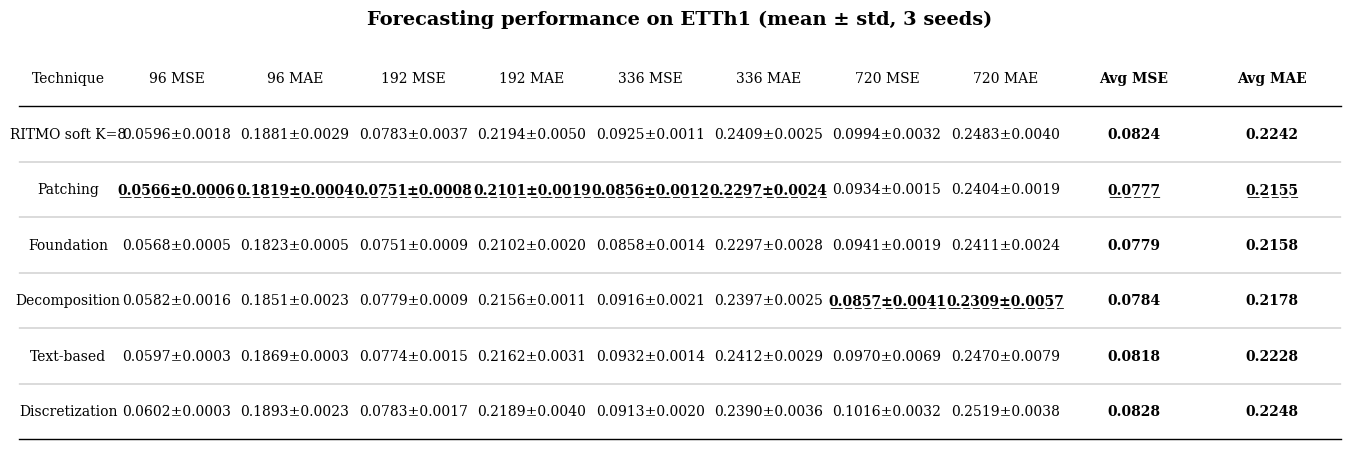

Saved: notebooks/figures_paper1/table_etth1.png


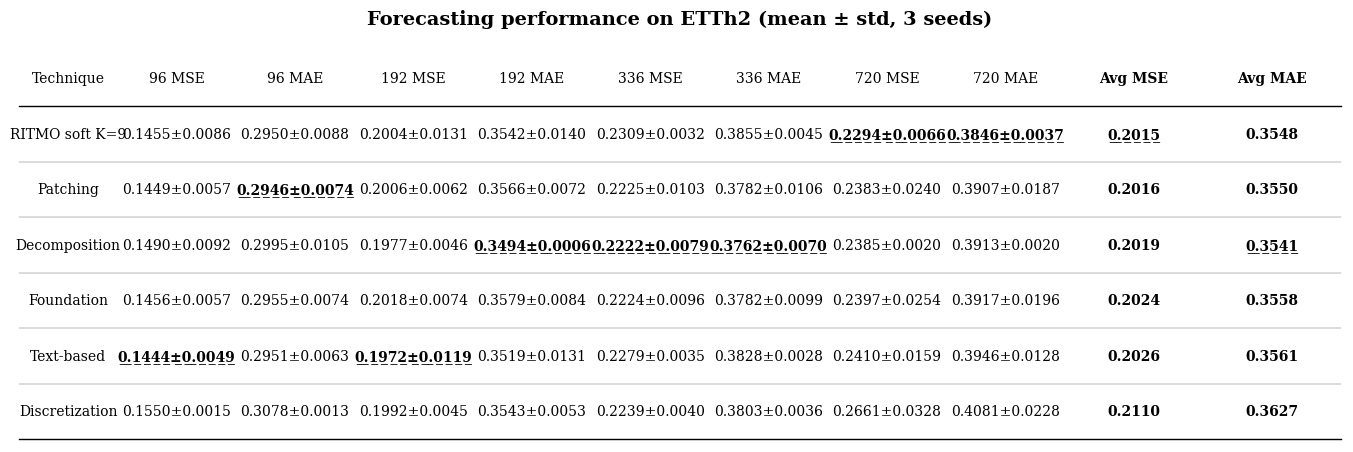

Saved: notebooks/figures_paper1/table_etth2.png


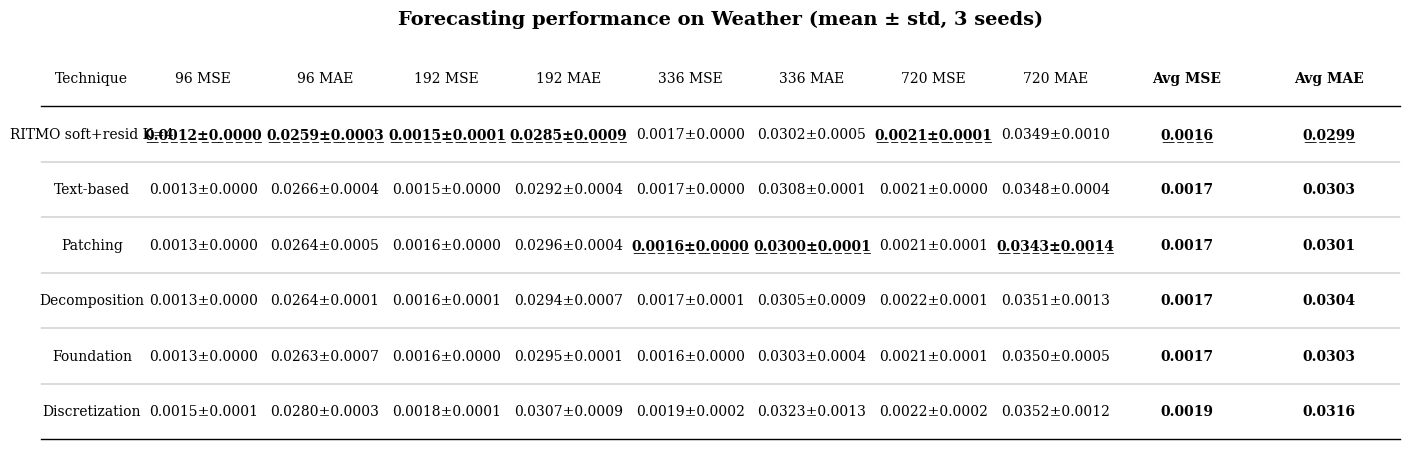

Saved: notebooks/figures_paper1/table_weather.png


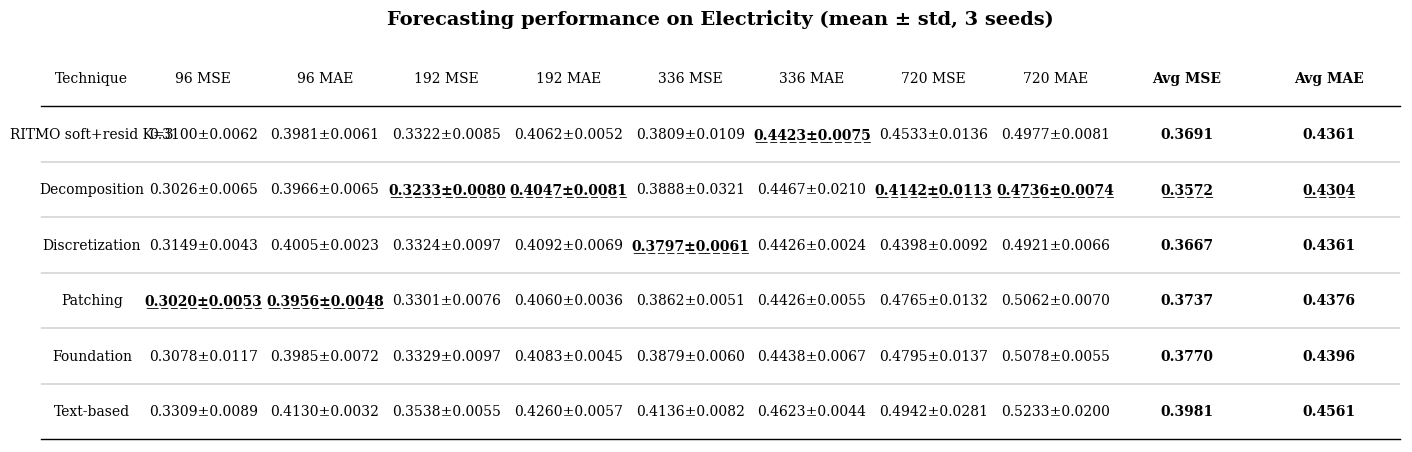

Saved: notebooks/figures_paper1/table_electricity.png


In [5]:
from plottable import Table, ColumnDefinition

def format_mean_std(mean, std):
    if pd.isna(mean):
        return '—'
    if pd.isna(std):
        return f'{mean:.4f}'
    return f'{mean:.4f}±{std:.4f}'

def render_table(ds, save_path):
    sub = agg[agg['dataset'] == ds].copy()
    if len(sub) == 0:
        print(f'No data for {ds}')
        return
    # Build DataFrame: rows = techniques (winning HMM first), cols = MSE/MAE × horizon + Avg.
    sub['avg_mse'] = sub.groupby(['technique', 'K'])['mse_mean'].transform(
        lambda x: x.mean() if len(x) == len(PRED_LENS) else np.nan
    )
    sub['tech_key'] = sub.apply(
        lambda r: f"{r['technique']}_K{int(r['K'])}" if not pd.isna(r['K']) else r['technique'], axis=1
    )
    # Orden: HMM primero (por avg MSE), luego baselines (por avg MSE)
    avg_by_tech = sub.groupby('tech_key')['mse_mean'].mean()
    hmm_techs = sorted([t for t in avg_by_tech.index if t.startswith('hmm')], key=lambda t: avg_by_tech[t])
    other_techs = sorted([t for t in avg_by_tech.index if not t.startswith('hmm')], key=lambda t: avg_by_tech[t])
    tech_order = hmm_techs + other_techs

    records = []
    for tk in tech_order:
        sub_t = sub[sub['tech_key'] == tk].set_index('pred_len')
        # Display name.
        if tk.startswith('hmm_'):
            base, K = tk.rsplit('_K', 1)
            disp = f"RITMO {TECH_NAMES_SIMPLE[base].split('(')[1].rstrip(')')} K={K}"
        else:
            disp = TECH_NAMES_SIMPLE.get(tk, tk)
        row = {'Technique': disp}
        mses, maes = [], []
        for pl in PRED_LENS:
            if pl in sub_t.index:
                r = sub_t.loc[pl]
                row[f'{pl} MSE'] = format_mean_std(r['mse_mean'], r['mse_std'])
                row[f'{pl} MAE'] = format_mean_std(r['mae_mean'], r['mae_std'])
                mses.append(r['mse_mean']); maes.append(r['mae_mean'])
            else:
                row[f'{pl} MSE'] = '—'; row[f'{pl} MAE'] = '—'
        row['Avg MSE'] = f'{np.nanmean(mses):.4f}' if mses else '—'
        row['Avg MAE'] = f'{np.nanmean(maes):.4f}' if maes else '—'
        # Internal ranking key: numeric mean MSE.
        row['_avg_mse_num'] = np.nanmean(mses) if mses else np.inf
        row['_avg_mae_num'] = np.nanmean(maes) if maes else np.inf
        records.append(row)

    df_tab = pd.DataFrame(records).set_index('Technique')
    df_disp = df_tab.drop(columns=['_avg_mse_num', '_avg_mae_num'])

    # Identify best per column (ranking) using numeric helpers.
    best_per_col = {}
    for col in df_disp.columns:
        if 'MSE' in col:
            num_col = '_avg_mse_num' if col.startswith('Avg') else None
            if num_col:
                best_per_col[col] = df_tab[num_col].idxmin()
            else:
                # For horizon columns: parse the formatted string.
                vals = df_disp[col].apply(lambda s: float(s.split('±')[0]) if s != '—' else np.inf)
                best_per_col[col] = vals.idxmin()
        elif 'MAE' in col:
            num_col = '_avg_mae_num' if col.startswith('Avg') else None
            if num_col:
                best_per_col[col] = df_tab[num_col].idxmin()
            else:
                vals = df_disp[col].apply(lambda s: float(s.split('±')[0]) if s != '—' else np.inf)
                best_per_col[col] = vals.idxmin()

    # Plot.
    n_cols = len(df_disp.columns)
    max_name = max(len(t) for t in df_disp.index)
    fig_w = max(14, 1.4 * n_cols + max_name * 0.08 + 2)
    fig_h = max(2.8, 0.6 * len(df_disp) + 1.5)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    col_defs = [ColumnDefinition(
        name='index',
        width=2.4 if max_name > 18 else 1.8,
        textprops={'fontsize': 10, 'ha': 'left'},
    )]
    for col in df_disp.columns:
        is_avg = col.startswith('Avg')
        col_defs.append(ColumnDefinition(
            name=col, width=1.4 if is_avg else 1.2,
            textprops={'fontsize': 10, 'fontweight': 'bold' if is_avg else 'normal',
                       'ha': 'center'},
        ))
    tab = Table(
        df_disp, column_definitions=col_defs,
        textprops={'fontsize': 10, 'ha': 'center'},
        row_dividers=True, col_label_divider=True, footer_divider=True,
        ax=ax,
    )
    # Underline best entry per column.
    for col_idx, col in enumerate(df_disp.columns):
        for row_idx, tech in enumerate(df_disp.index):
            cell = tab.cells[row_idx, col_idx + 1]
            if col in best_per_col and tech == best_per_col[col]:
                cell.text.set_fontweight('bold')
                cell.text.set_text('\u0332'.join(cell.text.get_text()) + '\u0332')
    ax.set_title(f'Forecasting performance on {DS_LABELS[ds]} (mean ± std, 3 seeds)', fontsize=14, fontweight='bold', pad=18)
    fig.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    fig.savefig(save_path.replace('.png', '.pdf'), bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'Saved: {save_path}')

for ds in DS_ORDER:
    render_table(ds, str(FIG_DIR / f'table_{DS_LABELS[ds].lower()}.png'))

## 5. MSE bar charts with error bars (4 panels)

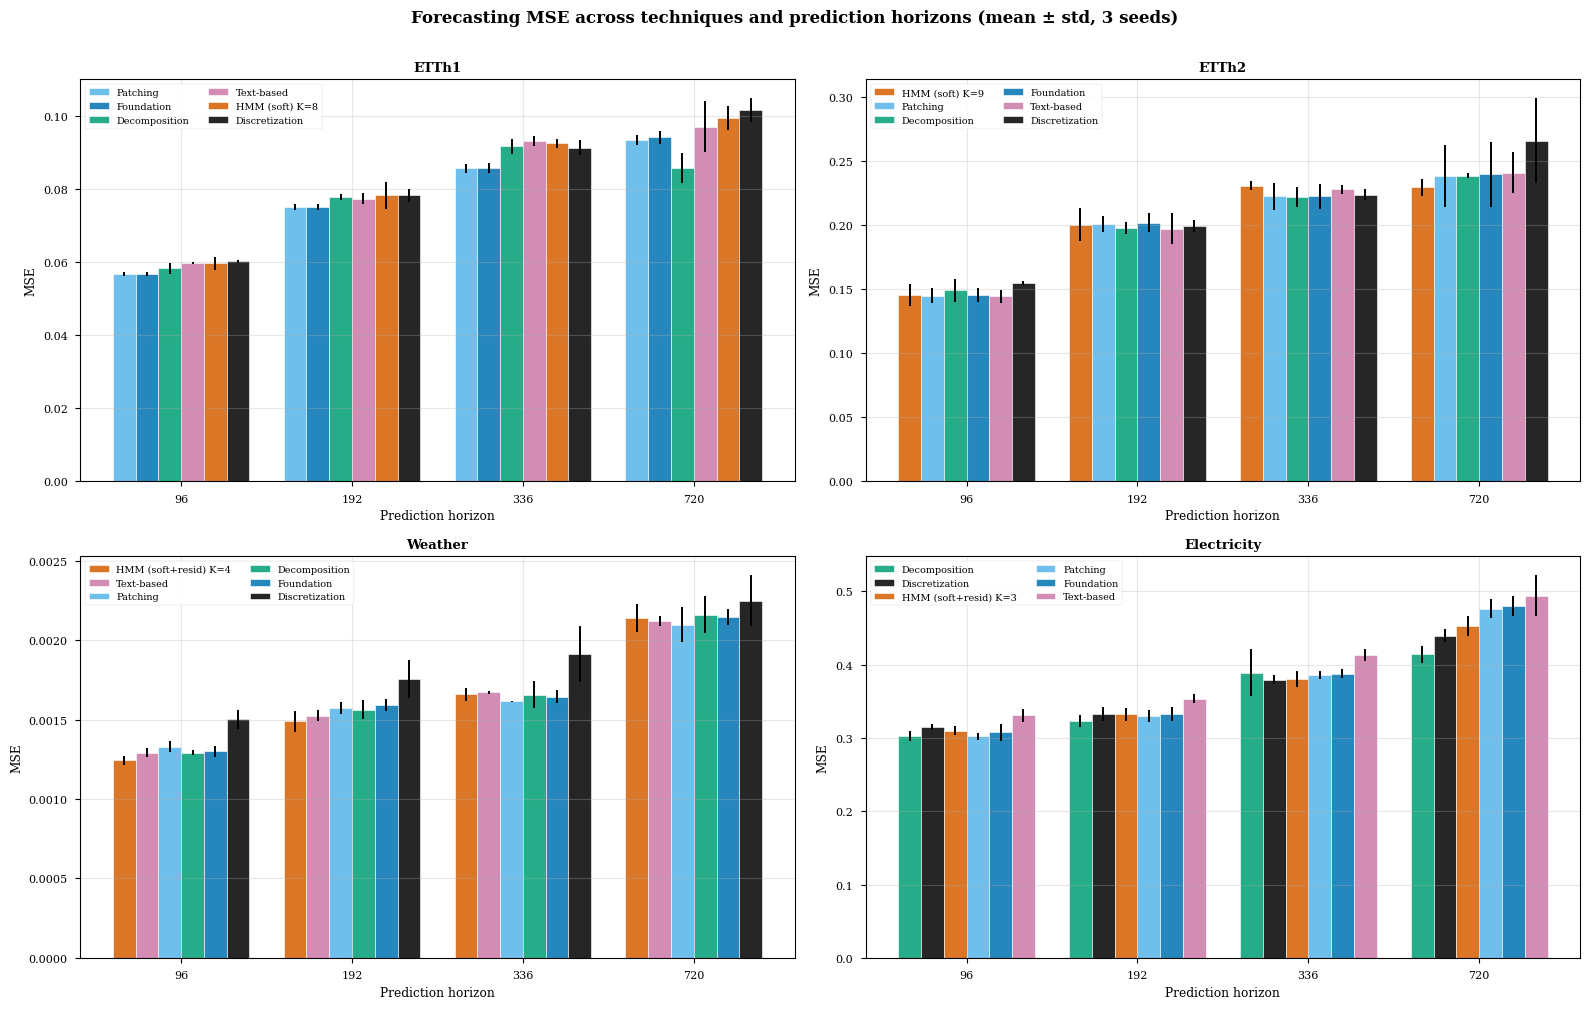

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i_ds, ds in enumerate(DS_ORDER):
    ax = axes[i_ds]
    sub = agg[agg['dataset'] == ds].copy()
    if len(sub) == 0:
        ax.set_title(f'{DS_LABELS[ds]} (no data)')
        continue
    sub['tech_key'] = sub.apply(
        lambda r: f"{r['technique']}_K{int(r['K'])}" if not pd.isna(r['K']) else r['technique'], axis=1
    )
    avg_by_tech = sub.groupby('tech_key')['mse_mean'].mean()
    techs = sorted(avg_by_tech.index, key=lambda t: avg_by_tech[t])
    n_t = len(techs)
    x = np.arange(len(PRED_LENS))
    width = 0.8 / n_t

    for i_t, tk in enumerate(techs):
        sub_t = sub[sub['tech_key'] == tk].set_index('pred_len')
        means = [sub_t.loc[pl, 'mse_mean'] if pl in sub_t.index else np.nan for pl in PRED_LENS]
        stds  = [sub_t.loc[pl, 'mse_std']  if pl in sub_t.index else 0      for pl in PRED_LENS]
        base = tk.rsplit('_K', 1)[0] if '_K' in tk else tk
        color = TECH_COLOR.get(base, COLORS_OI[7])
        label = TECH_NAMES_SIMPLE.get(base, base)
        if 'hmm' in tk and '_K' in tk:
            label += f' K={tk.rsplit("_K",1)[1]}'
        ax.bar(x + i_t * width - 0.4 + width/2, means, width, yerr=stds,
               label=label, color=color, alpha=0.85, edgecolor='white',
               linewidth=0.5, capsize=3)

    ax.set_xticks(x); ax.set_xticklabels([str(pl) for pl in PRED_LENS])
    ax.set_xlabel('Prediction horizon')
    ax.set_ylabel('MSE')
    ax.set_title(DS_LABELS[ds], fontweight='bold')
    ax.legend(fontsize=7, loc='best', framealpha=0.9, ncol=2)

plt.suptitle('Forecasting MSE across techniques and prediction horizons (mean ± std, 3 seeds)',
             fontweight='bold', y=1.005)
plt.tight_layout()
for ext in ['png', 'pdf', 'svg']:
    fig.savefig(FIG_DIR / f'mse_comparison_all_3seeds.{ext}', dpi=300, bbox_inches='tight')
plt.show()

## 6. Summary CSV export

In [7]:
# Long table: dataset, technique, K, pred_len, mse_mean, mse_std, mae_mean, mae_std, n_seeds.
out_csv = FIG_DIR / 'paper1_full_results.csv'
agg.to_csv(out_csv, index=False)
print(f'CSV completo: {out_csv}')

# Summary table with mean over horizons (one row per (dataset, technique)).
summary = agg.groupby(['dataset', 'technique', 'K'], dropna=False).agg(
    avg_mse=('mse_mean', 'mean'), avg_mae=('mae_mean', 'mean'),
    std_mse_avg=('mse_std', 'mean'), std_mae_avg=('mae_std', 'mean'),
).reset_index().sort_values(['dataset', 'avg_mse'])
out_summary = FIG_DIR / 'paper1_summary.csv'
summary.to_csv(out_summary, index=False)
print(f'Summary: {out_summary}')
summary

CSV completo: notebooks/figures_paper1/paper1_full_results.csv
Summary: notebooks/figures_paper1/paper1_summary.csv


,dataset,technique,K,avg_mse,avg_mae,std_mse_avg,std_mae_avg
4,ETTh1,patching,NaN,0.077695,0.215514,0.001027,0.001664
2,ETTh1,foundation,NaN,0.077920,0.215849,0.001181,0.001918
0,ETTh1,decomposition,NaN,0.078353,0.217828,0.002143,0.002905
5,ETTh1,text_based,NaN,0.081825,0.222799,0.002516,0.003541
3,ETTh1,hmm_soft,8.0,0.082438,0.224207,0.002446,0.003579
1,ETTh1,discretization,NaN,0.082838,0.224788,0.001817,0.003418
9,ETTh2,hmm_soft,9.0,0.201542,0.354846,0.007882,0.007752
10,ETTh2,patching,NaN,0.201568,0.355024,0.011528,0.010976
6,ETTh2,decomposition,NaN,0.201856,0.354088,0.005918,0.005033
8,ETTh2,foundation,NaN,0.202370,0.355812,0.012004,0.011310
